In [9]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.qasm3 import dumps as qasm3_dumps
from qiskit.qasm2 import dumps as qasm2_dumps

In [2]:
qreg_q = QuantumRegister(3, 'q')
creg_c = ClassicalRegister(3, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

In [3]:
circuit.h(qreg_q[2])
circuit.cx(qreg_q[2], qreg_q[1])
circuit.cx(qreg_q[2], qreg_q[0])
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])
circuit.measure(qreg_q[2], creg_c[2])

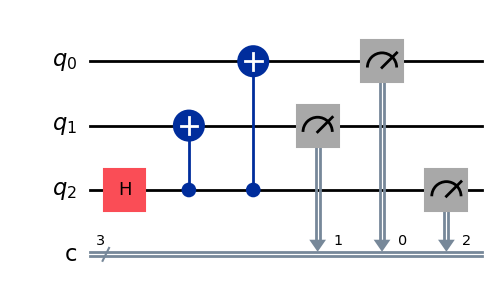

In [4]:
circuit.draw(output="mpl")

In [5]:
print(qasm3_dumps(circuit))

OPENQASM 3.0;
include "stdgates.inc";
bit[3] c;
qubit[3] q;
h q[2];
cx q[2], q[1];
cx q[2], q[0];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];



In [26]:
print(qasm2_dumps(circuit))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[2];
cx q[2],q[1];
cx q[2],q[0];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


In [35]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2 as AerSampler

In [37]:
pass_manager = generate_preset_pass_manager(
    optimization_level=2, backend=AerSimulator())
isa_circuit = pass_manager.run(circuit)
noise_model = NoiseModel()

sampler = AerSampler(options={"backend_options": {"noise_model": noise_model}})
job = sampler.run([isa_circuit], shots=1024)
result = job.result()[0]
print(result)

SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=3>)), metadata={'shots': 1024, 'circuit_metadata': {}, 'simulator_metadata': {'time_taken_parameter_binding': 9.257e-06, 'time_taken_execute': 0.004294957, 'omp_enabled': True, 'max_gpu_memory_mb': 0, 'max_memory_mb': 27320, 'parallel_experiments': 1}})
